In [75]:
import torch
import joblib
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [48]:
data1 = pd.read_csv(r"C:\Users\HP\Desktop\contexual model data\product_classification_dataset.csv")
data2 = pd.read_csv(r"C:\Users\HP\Desktop\contexual model data\product_classification_dataset_2.csv")
data3 = pd.read_csv(r"C:\Users\HP\Desktop\contexual model data\product_classification_dataset_3.csv")
data4 = pd.read_csv(r"C:\Users\HP\Desktop\contexual model data\product_feedback_dataset_4.csv")
data5 = pd.read_csv(r"C:\Users\HP\Desktop\contexual model data\product_feedback_dataset_5.csv")

fulldata = pd.concat([data1, data2, data3, data4, data5], ignore_index=True)
fulldata

,text,product
0,"Average gaming, does the job",ipad
1,My Garmin: Mixed feelings about the heart rate,watch
2,Best wifi I've ever experienced,laptop
3,My AirPods Max: The pressure stands out from o...,airpods
4,The voice assistant quality is unacceptable,airpods
...,...,...
26995,"The headphones battery rate standard, which is...",airpods
26996,"The selfies consider phone expected, which is ...",phone
26997,"The multitasking enjoy remarkable, which is ir...",laptop
26998,What I view about the tip is that it's moderat...,ipad


In [49]:
print(f"Dataset shape: {fulldata.shape}")
print(f"Product distribution:\n{fulldata['product'].value_counts()}")

Dataset shape: (27000, 2)
Product distribution:
product
ipad       5400
watch      5400
laptop     5400
airpods    5400
phone      5400
Name: count, dtype: int64


In [53]:
class ProductDataset(Dataset):
    """Custom dataset class for product classification"""
    
    def __init__(self, texts, labels, tokenizer, max_length=32):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [54]:
def compute_metrics(eval_pred):
  """Compute accuracy metrics for evaluation"""
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)
  return {'accuracy': accuracy_score(labels, predictions)}


In [55]:
label_encoder = LabelEncoder() # airpods: 0 | ipad: 1 | laptop: 2 | phone: 3 | watch: 4
fulldata['encoded_product'] = label_encoder.fit_transform(fulldata['product'])
fulldata['encoded_product'].value_counts()

encoded_product
1    5400
4    5400
2    5400
0    5400
3    5400
Name: count, dtype: int64

In [56]:
X = fulldata['text'].values
y = fulldata['encoded_product'].values

In [65]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_val)}")

Training set size: 21600
Test set size: 5400


In [59]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=5)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


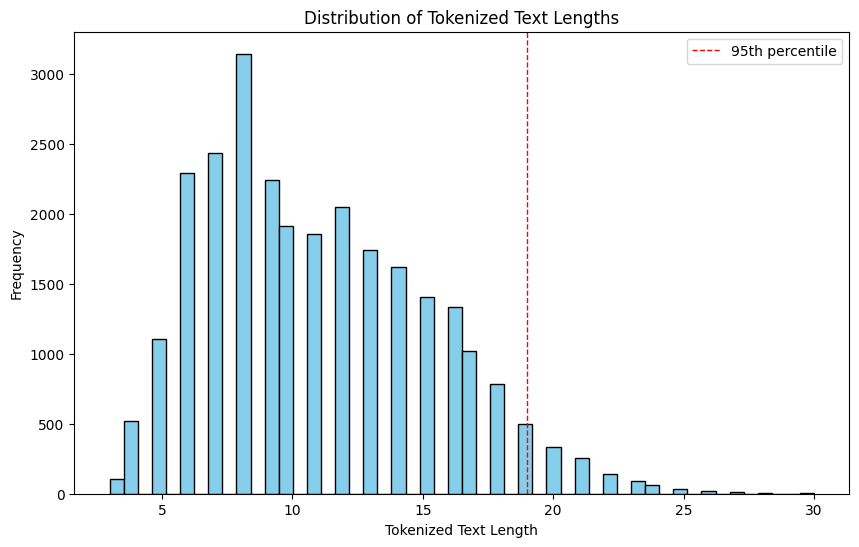

Max length: 30
95th percentile: 19
99th percentile: 22
Number of samples > 32: 0


In [60]:
# Visualize the distribution of tokenized text lengths to choose the best max_length

lengths = [len(tokenizer.tokenize(str(text))) for text in fulldata['text']]

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Tokenized Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Tokenized Text Lengths")
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='dashed', linewidth=1, label='95th percentile')
plt.legend()
plt.show()

print(f"Max length: {max(lengths)}")
print(f"95th percentile: {int(np.percentile(lengths, 95))}")
print(f"99th percentile: {int(np.percentile(lengths, 99))}")
print(f"Number of samples > 32: {sum(l > 32 for l in lengths)}")

In [67]:
train_dataset = ProductDataset(X_train, y_train, tokenizer)
val_dataset = ProductDataset(X_val, y_val, tokenizer)

In [68]:
training_args = TrainingArguments(
      output_dir='./product_model',
      num_train_epochs=3,
      weight_decay=0.01,
      logging_dir='./logs',
      logging_steps=50,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="accuracy",
      greater_is_better=True,
      save_total_limit=1,
      report_to="none"
    )

In [69]:
trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=val_dataset,
      compute_metrics=compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

In [70]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.221500,0.201663,0.938333
2,0.174000,0.133736,0.957593
3,0.095900,0.116589,0.963704


TrainOutput(global_step=8100, training_loss=0.2527824866035838, metrics={'train_runtime': 14703.712, 'train_samples_per_second': 4.407, 'train_steps_per_second': 0.551, 'total_flos': 1065628476979200.0, 'train_loss': 0.2527824866035838, 'epoch': 3.0})

In [71]:
training_args = TrainingArguments(
      output_dir='./product_model',
      num_train_epochs=4,
      weight_decay=0.01,
      logging_dir='./logs',
      logging_steps=50,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="accuracy",
      greater_is_better=True,
      save_total_limit=1,
      report_to="none"
    )
trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=val_dataset,
      compute_metrics=compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
trainer.train(resume_from_checkpoint="product_model\checkpoint-8100")

Epoch,Training Loss,Validation Loss,Accuracy
4,0.058700,0.113438,0.964815


TrainOutput(global_step=10800, training_loss=0.025066028723010312, metrics={'train_runtime': 4685.6381, 'train_samples_per_second': 18.439, 'train_steps_per_second': 2.305, 'total_flos': 1420837969305600.0, 'train_loss': 0.025066028723010312, 'epoch': 4.0})

In [ ]:
trainer.save_model('./product_classifier')
tokenizer.save_pretrained('./product_classifier')
joblib.dump(label_encoder, './product_classifier/label_encoder.pkl')

['./product_classifier/label_encoder.pkl']

In [84]:
def classify_product(text, model, tokenizer, label_encoder, max_length=32):
    """
    Predict the product class for a single input text.
    Returns the predicted product label and confidence score.
    """
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_idx = torch.argmax(probs, dim=-1).item()
    predicted_product = label_encoder.inverse_transform([pred_idx])[0]
    return predicted_product

In [ ]:
classify_model = AutoModelForSequenceClassification.from_pretrained("product_classifier")
text = "the screen brightness is very bad under the sun"
text2 = "looks like there is no thermal paste on this cpu"
text3 = "i think the heartbeat measurements is really accurate"

In [86]:
print(classify_product(text, classify_model, tokenizer, label_encoder))
print(classify_product(text2, classify_model, tokenizer, label_encoder))
print(classify_product(text3, classify_model, tokenizer, label_encoder))

phone
laptop
watch
